# 3章 スイッチとMACアドレス

本章では、いよいよ3個以上のノードから構成されるローカルネットワークについて学習していきます。
これまでは、1対1でのパケット転送しかできず、「ネットワーク」感が弱めだったかと思います。
ネットワーク上の住所に当たるアドレスや、それを用いたパケットの中継などについて、実装しながら学んでいきましょう。
前章と比べると実装内容が簡単ですので、前の章で少し躓いた方も、それは一旦忘れて進めて大丈夫です。

## ローカルネットワークとは

ローカルネットワーク（Local Area Network、LAN）は、一定の範囲内（例えば、家庭、オフィス、学校など）にある複数のデバイス（通信ノード）を接続するネットワークです。
ローカルネットワークを理解するためには、基本的な概念とその構成要素について学ぶことが重要です。

### ローカルネットワークの基本

ローカルネットワークは、以下のような特徴を持っています：

1. **限定された範囲：** LANは通常、小規模な地理的範囲（例えば、ビル内やキャンパス内）に限定されています。
2. **高速通信：** LANは、高速でデータを転送することができます。
3. **プライベートネットワーク：** LANはプライベートなネットワークであり、外部のインターネットとはルータやファイアウォールを介して接続されます。

### ローカルネットワークの構成要素

ローカルネットワークは、主に以下の要素で構成されます：

1. **通信ノード：** コンピュータ、プリンタ、サーバなどのデバイスです。これらはネットワーク上でデータを送受信します。ここまでに`Node`クラスとして実装してきました。
2. **通信メディア（ケーブルや無線）：** デバイス間の物理的な接続には、イーサネットケーブルやWi-Fiなどが使用されます。これは`Link`クラスとして実装してきました。
3. **スイッチ：** ネットワーク内のデバイスを物理的に接続し、パケットの中継を行います。本章では、このスイッチを`Switch`クラスとして実装していきます。
4. **ルータ：** 異なるネットワーク間でデータをルーティングするデバイスです。例えば、LANとインターネットを接続します。これは本章ではなく、もう少し後で扱っていきます。

### ローカルネットワークの動作
ローカルネットワークでは、以下のようなプロセスが行われます：

1. **データの送受信：** ユーザがデータ（例えば、電子メール、ファイル、ウェブページのリクエストなど）をパケットとして送信すると、そのパケットはネットワーク上を通って目的地へと送られます。
2. **アドレス指定と中継・ルーティング：** 送信されるパケットには宛先アドレスが含まれており、ルータやスイッチはこれを使用してデータを適切なデバイスへと転送します。特にスイッチではMACアドレスと呼ばれるアドレス情報が用いられます。
3. **セキュリティ：** ネットワークはファイアウォールや暗号化を通じてセキュリティを確保します。本書の後半で扱います。


### 既存クラスのインポート
さて、本章でのシミュレーションの実装や実行に向けて準備を進めていきましょう。
前章での拡張により、コードが長くなってきました。
これを全て本ページにも掲載していると見にくくなってしまうので、前章までに作成したコードは外部から読み込むこととし、新しい部分やアップデート分のみを掲載することとします。
本書のコードをアップロードしてあるGitHubレポジトリから、必要なファイルをインポートするため、以下のコードブロックを実行してください。


In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

Cloning into 'network-simulator'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 14 (delta 6), reused 0 (delta 0), pack-reused 0
Receiving objects: 100% (14/14), 12.40 KiB | 2.07 MiB/s, done.
Resolving deltas: 100% (6/6), done.


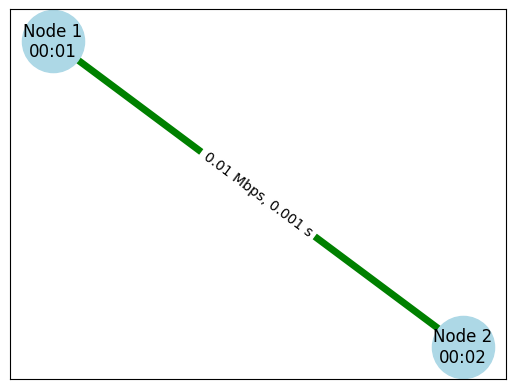

Src-Dst Pair: ('00:01', '00:02')
Total Sent Packets: 10
Total Sent Bytes: 1250
Total Received Packets: 10
Total Received Bytes: 1250
Average Throughput (bps): 1110.9876680368848
Average Delay (s): 0.0009999999999999343
Lost Packets: 0

Src-Dst Pair: ('00:02', '00:01')
Total Sent Packets: 30
Total Sent Bytes: 3750
Total Received Packets: 30
Total Received Bytes: 3750
Average Throughput (bps): 5171.52215135321
Average Delay (s): 0.0010000000000001859
Lost Packets: 0



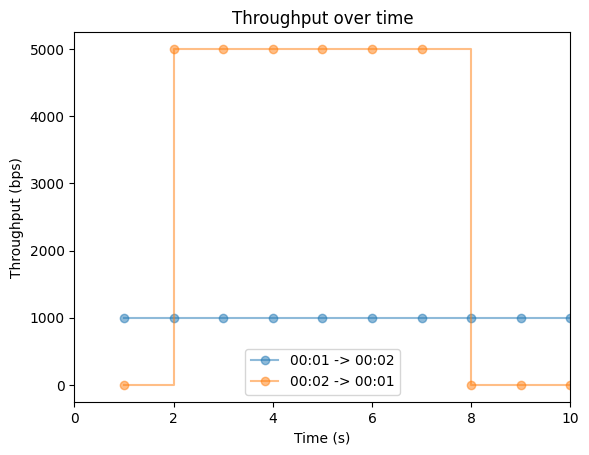

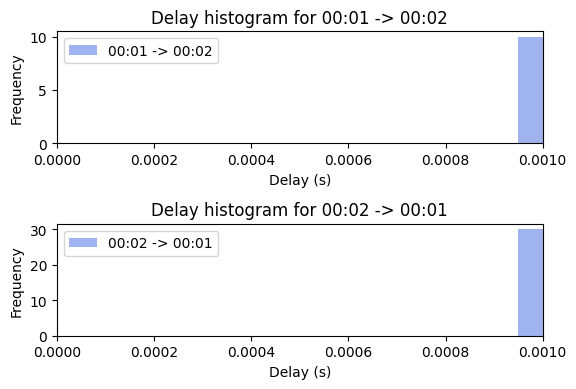

In [ ]:
# 必要なクラスをインポートします
from sec3a.NetworkEventScheduler import NetworkEventScheduler
from sec3a.Node import Node
from sec3a.Link import Link

# グローバルネットワークイベントスケジューラのインスタンスを新たに作成
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=False)

# ノードとリンクの設定
node1 = Node(node_id=1, address="00:01", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id=2, address="00:02", network_event_scheduler=network_event_scheduler)
link1 = Link(node1, node2, bandwidth=10000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# 通信アプリケーションの設定
node1.set_traffic(destination="00:02", bitrate=1000, start_time=1.0, duration=10.0, burstiness=1.0, header_size=40, payload_size=85)
node2.set_traffic(destination="00:01", bitrate=5000, start_time=2.0, duration=6.0, burstiness=1.0, header_size=40, payload_size=85)

# イベントスケジューラを実行
network_event_scheduler.run()

# 結果を確認
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)

## スイッチ
### コンピュータネットワークにおけるスイッチ
コンピュータネットワークにおける「スイッチ」とは、複数のデバイスを物理的に接続し、ネットワーク内でデータの転送を効率的に行うためのデバイスです。
つまりスイッチの役割は、パケットを受け取り、そのパケットが送信されるべき宛先へと転送することです。
このときに宛先の判断に用いるのが、パケットのヘッダに書き込まれているMACアドレスと呼ばれるアドレス情報です。
これは、手紙でいう宛名のことです。
ちなみに、後述しますがスイッチが扱うパケットのことを、正確にはフレームと呼びますが、煩雑なのでここではパケットという呼び名で統一します。
また規模の小さなスイッチは、ブリッジと呼ばれます。
家庭向けのような小型の機種については、ハブやスイッチングハブなどと呼ばれることも多いです。
このような機種についても基本的な機能は変わりませんが、紛らわしいのでここではスイッチという呼称で統一します。

スイッチの機能や動作のポイントはいくつかありますが、ここからは実装しながら順番に触れていくことにします。

### `Switch`クラスの設計方針
まず、`Switch`クラスの基本的な部分を作成してみましょう。
スイッチは、コンピュータネットワークにおいてデータパケットを適切な宛先に転送するための重要なデバイスです。
この`Switch`クラスは、ネットワーク内でスイッチの基本的な動作をシミュレートするために設計します。

- **リンクの管理**:
スイッチは複数のデバイスや他のスイッチとの間でパケットを中継するため、複数のリンクを備えます。
イーサネットスイッチなどであれば、何本ものツイストペアケーブルや光ファイバを接続できるように作られています。
大型のスイッチであれば、数十本、数百本のケーブルを接続することもあります。
`Switch`クラスにはlinksというリストを用意し、これにはスイッチに接続されている全てのリンクが含まれます。新しいリンクが追加されると、このリストに追加されます。

- **パケットの転送とロギング**:
スイッチはネットワーク上でデータパケットを受信し、それを適切な宛先に転送する役割を担います。
`Switch`クラスでは、`receive_packet`メソッドがパケットを受信し、`forward_packet`メソッドがフォワーディングテーブルに基づいてパケットを適切なリンクに転送します。また、パケットの受信、転送、損失に関する情報は、ネットワークイベントスケジューラを通じてログに記録されます。

- **フォワーディングテーブルの利用**:
スイッチは、ネットワーク内のどのデバイスにデータを送るべきかを知るために、フォワーディングテーブル（転送テーブル）を使用します。
このテーブルは、各宛先アドレスに対応する出口リンク（接続先）を記録しています。
`Switch`クラスでは、フォワーディングテーブルを辞書として初期化し、宛先アドレスとリンクのマッピングを保持します。
これにより、スイッチは受信したパケットの宛先アドレスをテーブルで検索し、適切なリンクにパケットを転送します。

- **フォワーディングテーブルの更新**:
実際のスイッチでは、フォワーディングテーブルを自動的に更新しますが、その機能は後で実装します。
まずはシンプルに、静的にアドレスとリンクの関係をテーブルに書き込むように作ります。
`Switch`クラスには`update_forwarding_table`というメソッドを持たせ、これを使ってフォワーディングテーブルを更新できます。
このメソッドは、宛先アドレスとそれに対応するリンクをテーブルに追加します。



### `Switch`クラスの実装

`Switch`クラスは、ネットワーク内でスイッチがどのように機能するかを模擬するために設計されています。以下に、クラスの各部分について詳しく説明します。

#### 1. コンストラクタ (`__init__`メソッド)

```python
class Switch:
    def __init__(self, node_id, network_event_scheduler):
        # スイッチの初期化
        # network_event_scheduler: スイッチが属するネットワークイベントスケジューラへの参照
        # node_id: スイッチの一意の識別子
        # links: スイッチに接続されているリンクのリスト
        # forwarding_table: 宛先アドレスに基づいてパケットを転送するためのテーブル
        self.network_event_scheduler = network_event_scheduler
        self.node_id = node_id
        self.links = []
        self.forwarding_table = {}
        label = f'Switch {node_id}'
        self.network_event_scheduler.add_node(node_id, label)
```

- `network_event_scheduler`: このスイッチが属するネットワークイベントスケジューラへの参照です。これにより、スイッチはネットワーク上でのイベントを記録したり、他のネットワーク要素とやり取りすることができます。
- `node_id`: スイッチの識別子です。ネットワーク内でスイッチを一意に識別するために使用されます。
- `links`: スイッチに接続されているリンクのリストです。これにより、スイッチは複数のデバイスや他のスイッチと通信できます。
- `forwarding_table`: 宛先アドレスに基づいてパケットを転送するためのフォワーディングテーブルです。これは、宛先アドレスとそのアドレスに対応するリンクのマッピングを保持します。

#### 2. リンクの追加 (`add_link`メソッド)

```python
    def add_link(self, link):
        # スイッチに新しいリンクを追加するメソッド
        # 既にリストに存在しないリンクのみが追加される
        if link not in self.links:
            self.links.append(link)
```

- このメソッドは、スイッチに新しいリンクを追加します。スイッチはこれらのリンクを通じて他のデバイスやスイッチと通信します。

#### 3. フォワーディングテーブルの更新 (`update_forwarding_table`メソッド)

```python
    def update_forwarding_table(self, destination_address, link):
        # フォワーディングテーブルを更新するメソッド
        # destination_address: 宛先アドレス
        # link: その宛先へのパケットを転送するためのリンク
        self.forwarding_table[destination_address] = link
```

- このメソッドは、フォワーディングテーブルを更新します。特定の宛先アドレスに対して、どのリンクを通じてパケットを転送するかを指定します。

#### 4. パケットの受信と転送 (`receive_packet`および`forward_packet`メソッド)

```python
    def receive_packet(self, packet):
        # スイッチがパケットを受信した際の処理を行うメソッド
        # パケットが失われた場合（到着時間が-1）は、その情報をログに記録
        if packet.arrival_time == -1:
            self.network_event_scheduler.log_packet_info(packet, "lost", self.node_id)
            return
        # パケットが正常に到着した場合は、受信情報をログに記録し、転送処理を行う
        self.network_event_scheduler.log_packet_info(packet, "received", self.node_id)
        self.forward_packet(packet)

    def forward_packet(self, packet):
        # フォワーディングテーブルを使用してパケットを転送するメソッド
        # destination_address: パケットの宛先アドレス
        # 宛先アドレスがフォワーディングテーブルに存在する場合、対応するリンクにパケットを転送
        destination_address = packet.header["destination"]
        if destination_address in self.forwarding_table:
            link = self.forwarding_table[destination_address]
            self.network_event_scheduler.log_packet_info(packet, "forwarded", self.node_id)
            link.enqueue_packet(packet, self)
        else:
            # 宛先がテーブルにない場合の処理（現段階では未実装）
            pass
```

- `receive_packet`メソッドは、スイッチがパケットを受信したときに呼び出されます。パケットが正常に到着したか、失われたかに基づいて適切なアクションを実行します。
- `forward_packet`メソッドは、フォワーディングテーブルを参照して、パケットの宛先アドレスに基づいて適切なリンクにパケットを転送します。



In [ ]:
class Switch:
    def __init__(self, node_id, network_event_scheduler):
        # スイッチの初期化
        # network_event_scheduler: スイッチが属するネットワークイベントスケジューラへの参照
        # node_id: スイッチの一意の識別子
        # links: スイッチに接続されているリンクのリスト
        # forwarding_table: 宛先アドレスに基づいてパケットを転送するためのテーブル
        self.network_event_scheduler = network_event_scheduler
        self.node_id = node_id
        self.links = []
        self.forwarding_table = {}
        label = f'Switch {node_id}'
        self.network_event_scheduler.add_node(node_id, label)

    def add_link(self, link):
        # スイッチに新しいリンクを追加するメソッド
        # 既にリストに存在しないリンクのみが追加される
        if link not in self.links:
            self.links.append(link)

    def update_forwarding_table(self, destination_address, link):
        # フォワーディングテーブルを更新するメソッド
        # destination_address: 宛先アドレス
        # link: その宛先へのパケットを転送するためのリンク
        self.forwarding_table[destination_address] = link

    def receive_packet(self, packet):
        # スイッチがパケットを受信した際の処理を行うメソッド
        # パケットが失われた場合（到着時間が-1）は、その情報をログに記録
        if packet.arrival_time == -1:
            self.network_event_scheduler.log_packet_info(packet, "lost", self.node_id)
            return
        # パケットが正常に到着した場合は、受信情報をログに記録し、転送処理を行う
        self.network_event_scheduler.log_packet_info(packet, "received", self.node_id)
        self.forward_packet(packet)

    def forward_packet(self, packet):
        # フォワーディングテーブルを使用してパケットを転送するメソッド
        # destination_address: パケットの宛先アドレス
        # 宛先アドレスがフォワーディングテーブルに存在する場合、対応するリンクにパケットを転送
        destination_address = packet.header["destination"]
        if destination_address in self.forwarding_table:
            link = self.forwarding_table[destination_address]
            self.network_event_scheduler.log_packet_info(packet, "forwarded", self.node_id)
            link.enqueue_packet(packet, self)
        else:
            # 宛先がテーブルにない場合の処理（現段階では未実装）
            pass

    def __str__(self):
        # 接続されているノードのIDを取得
        connected_nodes = [link.node_x.node_id if self.node_id != link.node_x.node_id else link.node_y.node_id for link in self.links]
        connected_nodes_str = ', '.join(map(str, connected_nodes))
        return f"スイッチ(ID: {self.node_id}, 接続: {connected_nodes_str})"


### `Switch`クラスの利用

`Switch`クラスを用いることで，多数のノードからなるネットワークを構成し、パケットを中継・転送できるようになります。
ここでは、まずは簡単な例として，2つのノードをスイッチを介して接続してみましょう。
以下のようにシミュレーションのコードを作成します。

#### ネットワークイベントスケジューラの設定

まず、`NetworkEventScheduler`クラスのインスタンスを作成します。このインスタンスは、ネットワーク上で発生するさまざまなイベント（パケットの送受信など）を管理し、ネットワークの全体的な動作をコントロールします。

```python
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=False)
```

#### ノードとスイッチの設定

次に、ネットワーク内のノードとスイッチを設定します。ここでは、二つのノード（`node1`と`node2`）と一つのスイッチ（`switch1`）を作成します。

```python
node1 = Node(node_id="n1", address="00:01", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", address="00:02", network_event_scheduler=network_event_scheduler)
switch1 = Switch(node_id="s1", network_event_scheduler=network_event_scheduler)
```

#### リンクの設定

ノードとスイッチの間には物理的な接続が必要です。これを実現するために、`Link`クラスを使用して、ノードとスイッチの間にリンクを作成します。

```python
link1 = Link(node1, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(node2, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
```

#### スイッチのフォワーディングテーブルの設定

スイッチは、フォワーディングテーブルを使用して、どのリンクを通じてパケットを転送するかを決定します。ここでは、スイッチのフォワーディングテーブルを設定して、各ノード宛のパケットが適切なリンクを通じて転送されるようにします。

```python
switch1.update_forwarding_table(node1.address, link1)
switch1.update_forwarding_table(node2.address, link2)
```

#### トラフィックの設定とシミュレーションの実行

ノードから別のノードへのトラフィックを設定し、ネットワーク上でのデータの流れをシミュレートします。この例では、`node1`から`node2`へのトラフィックを設定しています。

```python
node1.set_traffic(destination="00:02", bitrate=10000, start_time=1.0, duration=10.0, burstiness=1.0, header_size=40, payload_size=85)
```

最後に、イベントスケジューラを実行して、設定したトラフィックのシミュレーションを開始します。

```python
network_event_scheduler.run()
```

#### 結果の確認

シミュレーションが完了した後、ネットワーク上でのパケットの流れやパフォーマンスに関するサマリを生成し、ネットワークの動作を分析します。

```python
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)
```


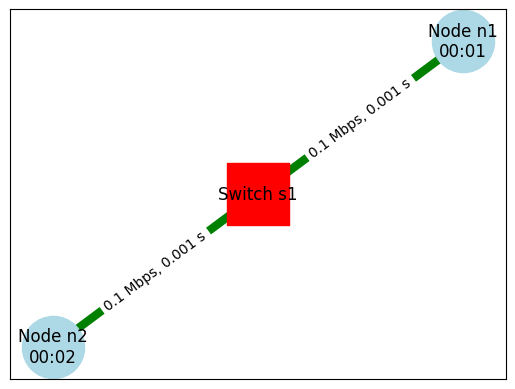

Src-Dst Pair: ('00:01', '00:02')
Total Sent Packets: 101
Total Sent Bytes: 12625
Total Received Packets: 101
Total Received Bytes: 12625
Average Throughput (bps): 10097.980403919239
Average Delay (s): 0.0019999999999998678
Lost Packets: 0



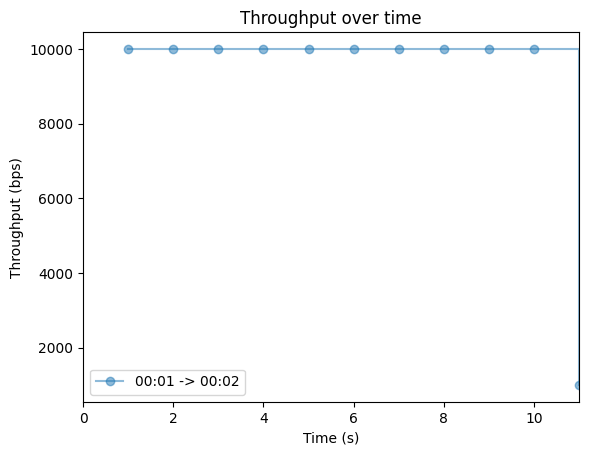

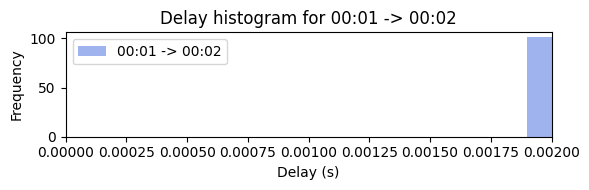

In [ ]:
from sec3a.NetworkEventScheduler import NetworkEventScheduler
from sec3a.Node import Node
from sec3a.Switch import Switch
from sec3a.Link import Link

# ネットワークイベントスケジューラのインスタンスを作成
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=False)

# ノードとスイッチの設定
node1 = Node(node_id="n1", address="00:01", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", address="00:02", network_event_scheduler=network_event_scheduler)
switch1 = Switch(node_id="s1", network_event_scheduler=network_event_scheduler)

# リンクの設定
# node1とswitch1、node2とswitch1をそれぞれリンクで接続
link1 = Link(node1, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(node2, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# スイッチのフォワーディングテーブルを設定
# node1のアドレス宛のパケットはlink1を通じて、node2のアドレス宛のパケットはlink2を通じて転送される
switch1.update_forwarding_table(node1.address, link1)
switch1.update_forwarding_table(node2.address, link2)

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# 通信アプリケーションの設定
# node1からnode2へのトラフィックを設定
node1.set_traffic(destination="00:02", bitrate=10000, start_time=1.0, duration=10.0, burstiness=1.0, header_size=40, payload_size=85)

# イベントスケジューラを実行
network_event_scheduler.run()

# 結果を確認
# ネットワーク上でのパケットの流れとパフォーマンスに関するサマリを生成
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)


### 課題
1. ノード4個を、スイッチ1個を介して接続しましょう。
2. フォワーディングテーブルを設定しましょう。
3. ノード間で任意のトラフィックを設定し、パケット転送を行ってみましょう。


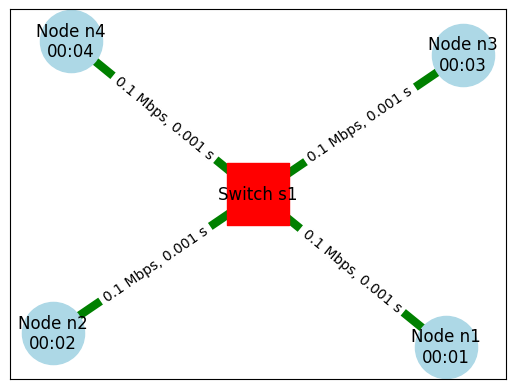

Src-Dst Pair: ('00:01', '00:02')
Total Sent Packets: 101
Total Sent Bytes: 12625
Total Received Packets: 101
Total Received Bytes: 12625
Average Throughput (bps): 10097.980403919239
Average Delay (s): 0.008435643564356166
Lost Packets: 0

Src-Dst Pair: ('00:01', '00:03')
Total Sent Packets: 200
Total Sent Bytes: 25000
Total Received Packets: 200
Total Received Bytes: 25000
Average Throughput (bps): 20096.463022508
Average Delay (s): 0.0037499999999998468
Lost Packets: 0

Src-Dst Pair: ('00:02', '00:04')
Total Sent Packets: 301
Total Sent Bytes: 37625
Total Received Packets: 301
Total Received Bytes: 37625
Average Throughput (bps): 30093.981203759336
Average Delay (s): 0.009740863787375136
Lost Packets: 0

Src-Dst Pair: ('00:03', '00:04')
Total Sent Packets: 400
Total Sent Bytes: 50000
Total Received Packets: 400
Total Received Bytes: 50000
Average Throughput (bps): 40052.067687994044
Average Delay (s): 0.008674999999999737
Lost Packets: 0



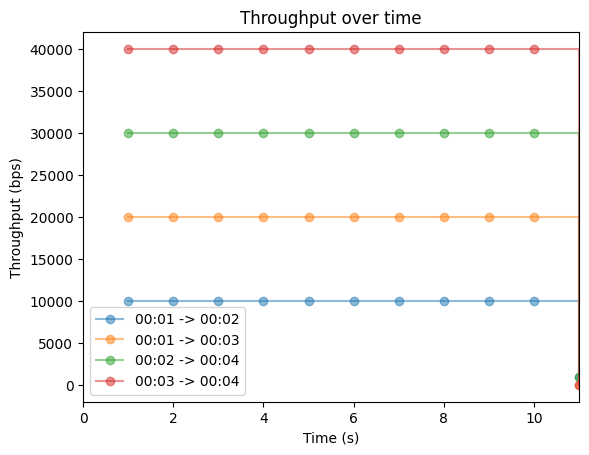

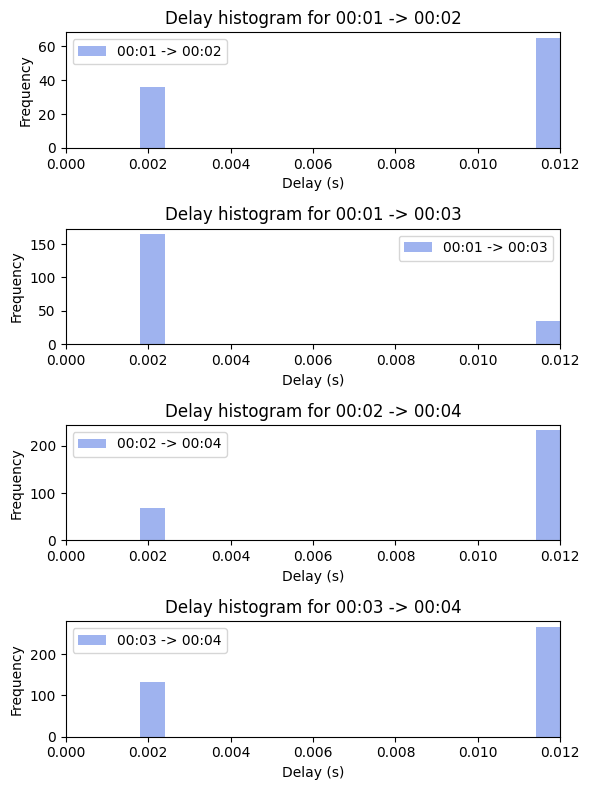

In [ ]:
# 課題の回答例
from simplenetwork_sec3a import NetworkEventScheduler
from simplenetwork_sec3a import Node
from simplenetwork_sec3a import Switch
from simplenetwork_sec3a import Link

# ネットワークイベントスケジューラのインスタンスを作成
network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=False)

# ノードとスイッチの設定
node1 = Node(node_id="n1", address="00:01", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", address="00:02", network_event_scheduler=network_event_scheduler)
node3 = Node(node_id="n3", address="00:03", network_event_scheduler=network_event_scheduler)
node4 = Node(node_id="n4", address="00:04", network_event_scheduler=network_event_scheduler)
switch1 = Switch(node_id="s1", network_event_scheduler=network_event_scheduler)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(node2, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link3 = Link(node3, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link4 = Link(node4, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# スイッチのフォワーディングテーブルを設定
switch1.update_forwarding_table(node1.address, link1)
switch1.update_forwarding_table(node2.address, link2)
switch1.update_forwarding_table(node3.address, link3)
switch1.update_forwarding_table(node4.address, link4)

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# 通信アプリケーションの設定
node1.set_traffic(destination=node2.address, bitrate=10000, start_time=1.0, duration=10.0, burstiness=1.0, header_size=40, payload_size=85)
node1.set_traffic(destination=node3.address, bitrate=20000, start_time=1.0, duration=10.0, burstiness=1.0, header_size=40, payload_size=85)
node2.set_traffic(destination=node4.address, bitrate=30000, start_time=1.0, duration=10.0, burstiness=1.0, header_size=40, payload_size=85)
node3.set_traffic(destination=node4.address, bitrate=40000, start_time=1.0, duration=10.0, burstiness=1.0, header_size=40, payload_size=85)

# イベントスケジューラを実行
network_event_scheduler.run()

# 結果を確認
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)


## MACアドレス

#### 標準アドレスの重要性
ここまで、アドレス情報を適当に定義して使ってきました。
ただし、当たり前ですが勝手に定義したアドレスでは、世界中の様々なデバイスと通信することはできません。
ネットワークに参加するあらゆるデバイスが、統一されたフォーマットのアドレスを利用することで、パケットを機械的に処理し、正しい宛先へ到達することができるのです。
このような統一化を「標準化」と呼び、策定されたフォーマットを「標準」と呼びます。
ここでは詳しくは述べませんが、標準化は大変重要な取り組みです。
標準に則った実装が行われているからこそ、巨大なネットワークであるインターネットが成立しているのです。

ローカルネットワークで用いられるアドレスが、MACアドレス（Media Access Control Address）です。
MACアドレスは、ネットワーク上のデバイスを一意に識別するために使用される重要な要素です。
以下に、MACアドレスの必要性とその役割について詳しく解説します。

### MACアドレスの基本

- **一意の識別子：** MACアドレスは、ネットワーク上の各デバイス（コンピュータ、スイッチ、ルータなど）に割り当てられる固有の識別子です。固有であるがゆえに、他のデバイスと間違えることなく、ネットワーク上でデバイスを特定し、正確なデータ転送を可能にします。

- **物理層のアドレス：** MACアドレスは、物理的なネットワークインターフェースに関連付けられています。一般的には、デバイスのネットワークインターフェースカード（NIC）に記録されています。

- **ローカルネットワークでの利用：** MACアドレスは、イーサネットやWi-Fiなどのローカルエリアネットワーク（LAN）技術において用いられます。MACアドレスでデバイスを認証することもある一方で、デバイスの特定を防ぐために偽装したアドレスが用いられるケースも多いです。

### MACアドレスの仕様

- **長さと形式：** MACアドレスは48ビット（6バイト）の長さで、16進数で表されます。例えば、「00:1A:2B:3C:4D:5E」のように、コロン（:）またはハイフン（-）で区切られた6つの2桁の数値で構成されます。

- **OUI（Organizationally Unique Identifier）：** MACアドレスの最初の3バイト（24ビット）は、OUIまたはベンダIDとして知られています。これは、デバイスの製造者を識別するためにIEEEによって割り当てられた一意のコードです。

- **製造者固有の部分：** 残りの3バイト（24ビット）は、製造者によって割り当てられ、その製造者の中で一意である必要があります。これにより、同じ製造者の異なるデバイスが区別されます。

### MACアドレスの実装

#### `Packet`クラスのアップデート
まず、`Packet`クラスに定義していたのは仮のaddress変数だったので，これをMACアドレスを表す名前に修正します。
これは単に概念の明確化のためであり、現時点ではパケットの挙動自体には影響を与えません。

```
class Packet:
    def __init__(self, source_mac, destination_mac, header_size, payload_size, network_event_scheduler):
        # ネットワークイベントスケジューラへの参照を保持
        self.network_event_scheduler = network_event_scheduler

        # パケットに一意のIDを割り当て
        self.id = str(uuid.uuid4())

        # パケットのヘッダ情報を設定
        # source: パケットの送信元MACアドレス
        # destination: パケットの宛先MACアドレス
        self.header = {
            "source_mac": source_mac,
            "destination_mac": destination_mac,
        }

        # 省略

    def __str__(self):
        # パケットの文字列表現を返す特殊メソッド
        # パケットの送信元MACアドレス、宛先MACアドレス、ペイロードを含む情報を出力
        return f'パケット(送信元: {self.header["source_mac"]}, 宛先: {self.header["destination_mac"]}, ペイロード: {self.payload})'
```


#### `Node`クラスのアップデートの概要

`Node`クラスは、ネットワーク上の個々のデバイス（ノード）を表すために使用されます。
このアップデートでは、ノードのアドレス指定を従来の形式からMACアドレス形式に変更し、MACアドレスの形式を検証する機能を追加しています。
MACアドレスは、ネットワーク上のデバイスを一意に識別するための国際標準の方法であり、各デバイスに固有のアドレスです。

- **MACアドレスの検証：** コンストラクタでは、渡された`mac_address`が有効なMACアドレス形式であるかどうかを`is_valid_mac_address`メソッドを使用して検証します。このメソッドは、正規表現を用いてMACアドレスの形式をチェックし、形式が不正である場合は`ValueError`を発生させます。

- **ノードの登録：** ノードは、自身のIDとMACアドレスを使用してネットワークイベントスケジューラに登録されます。これにより、ネットワーク上でのノードの存在が確立されます。

```
class Node:
    def __init__(self, node_id, mac_address, network_event_scheduler):
        # MACアドレスが正しい形式であるか確認
        if not self.is_valid_mac_address(mac_address):
            raise ValueError("無効なMACアドレス形式です。")

        self.network_event_scheduler = network_event_scheduler
        self.node_id = node_id
        self.mac_address = mac_address  # MACアドレス
        self.links = []
        label = f'Node {node_id}\n{mac_address}'
        self.network_event_scheduler.add_node(node_id, label)
```

- **`is_valid_mac_address`メソッド：** 与えられたMACアドレスが正しい形式（6つの2桁の16進数、コロンまたはハイフンで区切られる）であるかをチェックします。この検証は、ノードの作成時に不正なアドレスが使用されることを防ぎます。

```
    def is_valid_mac_address(self, mac_address):
        """MACアドレスが有効な形式かどうかをチェックする関数"""
        mac_format = re.compile(r'^([0-9A-Fa-f]{2}[:-]){5}([0-9A-Fa-f]{2})$')
        return bool(mac_format.match(mac_address))

    # 他のメソッドも同様にaddressをmac_addressへと修正
```


この変更に付随して、従来の（独自の）`address`表記だった点を、`mac_address`に修正します。
この微修正を行ったファイルを、simplenetwork_sec3b.pyとしてインポートします。


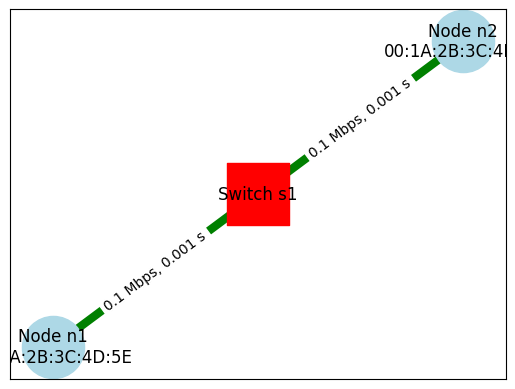

Src-Dst Pair: ('00:1A:2B:3C:4D:5E', '00:1A:2B:3C:4D:5F')
Total Sent Packets: 101
Total Sent Bytes: 12625
Total Received Packets: 101
Total Received Bytes: 12625
Average Throughput (bps): 10097.980403919239
Average Delay (s): 0.0019999999999998678
Lost Packets: 0



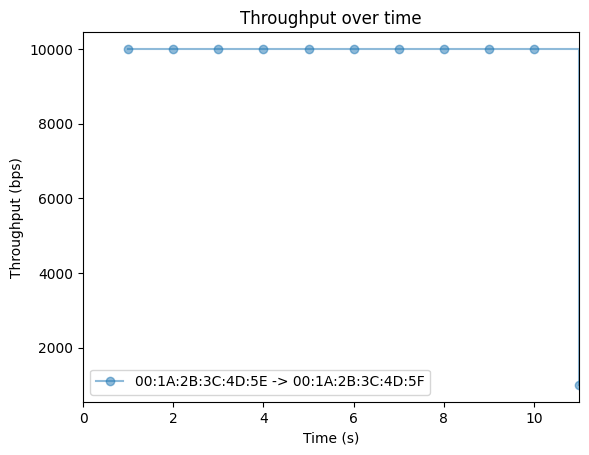

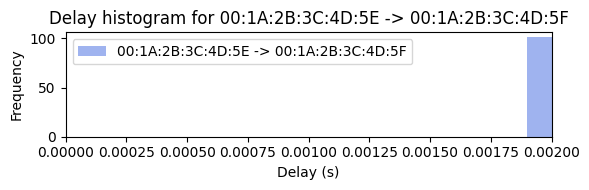

In [ ]:
# 必要なクラスをインポートします
from sec3b.NetworkEventScheduler import NetworkEventScheduler
from sec3b.Node import Node
from sec3b.Switch import Switch
from sec3b.Link import Link

network_event_scheduler = NetworkEventScheduler(log_enabled=True, verbose=False)

# ノードとスイッチの設定
node1 = Node(node_id="n1", mac_address="00:1A:2B:3C:4D:5E", network_event_scheduler=network_event_scheduler)
node2 = Node(node_id="n2", mac_address="00:1A:2B:3C:4D:5F", network_event_scheduler=network_event_scheduler)
switch1 = Switch(node_id="s1", network_event_scheduler=network_event_scheduler)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)
link2 = Link(node2, switch1, bandwidth=100000, delay=0.001, loss_rate=0.0, network_event_scheduler=network_event_scheduler)

# スイッチのフォワーディングテーブルを設定
switch1.update_forwarding_table(node1.mac_address, link1)
switch1.update_forwarding_table(node2.mac_address, link2)

# ネットワークのトポロジを描画
network_event_scheduler.draw()

# 通信アプリケーションの設定
node1.set_traffic(destination_mac="00:1A:2B:3C:4D:5F", bitrate=10000, start_time=1.0, duration=10.0, burstiness=1.0, header_size=40, payload_size=85)

# イベントスケジューラを実行
network_event_scheduler.run()

# 結果を確認
# ネットワーク上でのパケットの流れとパフォーマンスに関するサマリを生成
network_event_scheduler.generate_summary(network_event_scheduler.packet_logs)
network_event_scheduler.generate_throughput_graph(network_event_scheduler.packet_logs)
network_event_scheduler.generate_delay_histogram(network_event_scheduler.packet_logs)


## 演習課題

### 演習課題1: ネットワーク構築とMACアドレス設定
**目的**: スイッチを使用して簡単なネットワークを構築し、各ノードにMACアドレスを割り当てる。

**手順**:
1. 2つの`Switch`を`Link`により接続する。
2. 各`Switch`に対して2つずつ`Node`を接続する。
3. 各`Node`に一意のMACアドレスを割り当てる。

### 演習課題2: フォワーディングテーブルの作成
**目的**: フォワーディングテーブルを作成し、スイッチがネットワーク内でパケットを適切に転送することを確認する。

**手順**:
1. スイッチのフォワーディングテーブルを作成する。
2. 接続された各ノードのMACアドレスに基づいて、テーブルを設定する。

### 演習課題3: パケット転送のシミュレーション
**目的**: 構築したネットワークでパケット転送のシミュレーションを行い、ネットワークの動作を理解する。

**手順**:
1. 特定のノード間でトラフィック（パケット転送）を設定する。
2. ネットワーク上でパケットがどのように転送されるかを観察する。
3. 異なるノード間でトラフィックの設定を変えて、パケット転送の違いを観察する。


## 本章のまとめ
本章では、ローカルネットワークの主要な構成要素であるスイッチを作り、学習しました。
スイッチは、ノード同士を接続してパケットを中継転送します。
またローカルネットワーク上での標準アドレスとして、MACアドレスの書き方についても学習しました。
スイッチを用いてノードを連結し、フォワーディングテーブルを適切に設定することで、多くのノードからなるネットワークを構成することができます。

ただし、ノードが多くなってきたらフォワーディングテーブルをいちいち書いているわけにはいきません。
あるいは新しいノードを追加するとき、モバイルデバイスが移動してきたとき、そんなときにフォワーディングテーブルをどのように更新したら良いのでしょうか。
次章では、フォワーディングテーブルの更新などを中心に学んでいきます。
その結果として、いわゆるプラグアンドプレイのローカルネットワークを作れるようになります。
